### The log-vs-power controversy
Run both cells. Edit the `👈` values and re-run.

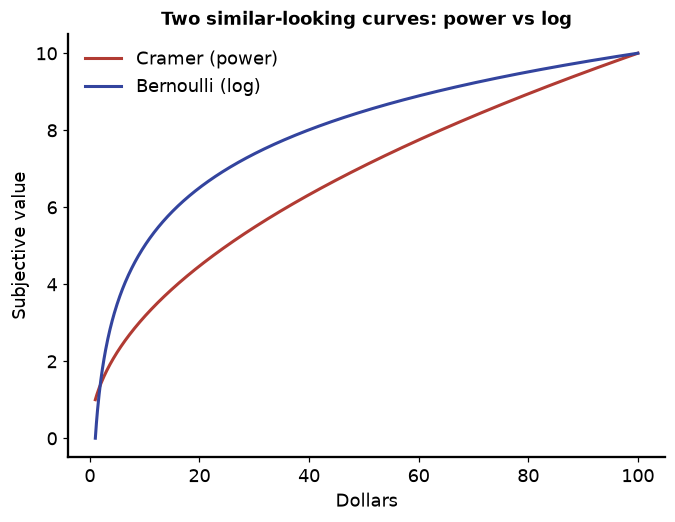

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
rng = np.random.default_rng()

# The same log-vs-power debate, much earlier: the subjective value of money.
dollars = np.linspace(1, 100, 999)
cramer_value    = dollars ** 0.5        # 👈 Cramer's power function (1728)
bernoulli_value = np.log10(dollars) * 5 # 👈 Bernoulli's log function (1738)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(dollars, cramer_value,    color="#b13b33", lw=2, label="Cramer (power)")
ax.plot(dollars, bernoulli_value, color="#33449e", lw=2, label="Bernoulli (log)")
ax.set(xlabel="Dollars", ylabel="Subjective value",
       title="Two similar-looking curves: power vs log")
ax.legend(loc="upper left")
plt.show()


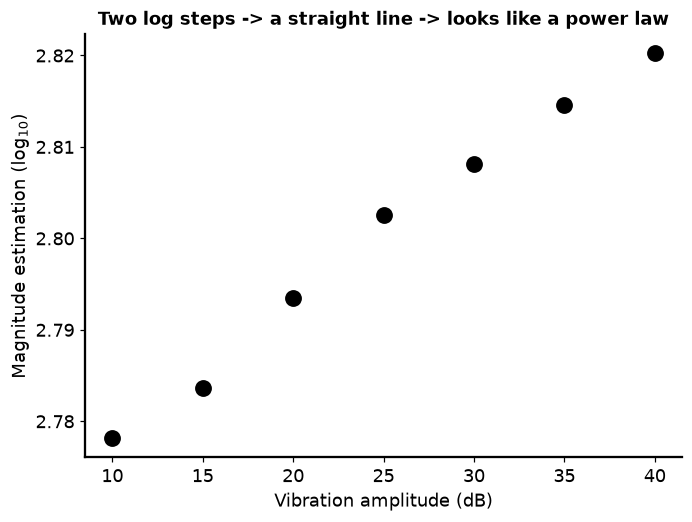

In [2]:
# MacKay's (1963) resolution: there is also a transformation from perception to
# RESPONSE. Applying the log law twice gets us back to a power law.
dBs = np.arange(10, 41, 5)
amplitudes = 10.0 ** (dBs / 20)

perceived = np.log(amplitudes)                                   # log perception
perceived = perceived + rng.standard_normal((100, dBs.size))
perceived = perceived - perceived.min() + 1                     # keep it positive
response  = np.log(perceived * 100)                             # a number also has a log magnitude
estimate  = response * 100

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(dBs, np.log10(estimate.mean(axis=0)), 100, color="k", zorder=3)
ax.set(xlabel="Vibration amplitude (dB)", ylabel="Magnitude estimation (log$_{10}$)",
       title="Two log steps -> a straight line -> looks like a power law")
plt.show()
